# Notebook Purpose: Testing the use of TP-classification threshold=12ms and overlap removal threshold=12ms after filtering human annotations to remove annotations < 3dB SNR. Then we look at what kind of overlaps are considered as true positives or false positives and how many over ALL files

## Imports Section:

In [61]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [62]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [63]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [64]:
import convert_between_detector_file_formats as conversion

## Function and Constant Definitions

In [65]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}
FILE_SITES = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}

RAVENPRO_TABLE_EXTENSION = ".txt"
RAVENPRO_TABLE_FORMAT = "\t"
RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
BD2_DETS_SAVE_DIR = Path(f'20250130__group_threshold_sweep_results')
TP_CLASSIFICATION_THRESHOLD = 0.012
OVERLAP_TIME_THRESHOLD = 0.012
SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

### Below are the functions used for converting between detector formats

In [66]:
def return_true_positives_using_human_df(human_df, machine_df):
    dist_matrix = np.zeros((len(machine_df), len(human_df)))
    association_matrix = np.zeros((len(machine_df), len(human_df)), dtype='bool')
    collect_human = pd.DataFrame()
    collect_bd2 = pd.DataFrame()
    for index in range(len(machine_df)):
        batdetect2_row = machine_df.iloc[index]
        dist_to_all_calls = ((human_df['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
        dist_matrix[index,:] = dist_to_all_calls
    
        dist_to_all_calls[np.abs(dist_to_all_calls)>=TP_CLASSIFICATION_THRESHOLD] = 1
        dist_to_all_calls[np.abs(dist_to_all_calls)<TP_CLASSIFICATION_THRESHOLD] = 0
        if np.abs(dist_to_all_calls-1).sum() > 1:
            collect_human = pd.concat([collect_human, human_df[dist_to_all_calls<0.5]])
            collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

        association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

    human_bd2_true_positives = human_df.loc[np.logical_or.reduce(association_matrix, axis=0)]
    machine_false_negatives = human_df.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
    machine_true_positives = machine_df.loc[np.logical_or.reduce(association_matrix, axis=1)]
    machine_false_positives = machine_df.loc[~(np.logical_or.reduce(association_matrix, axis=1))]

    separated_performance_dfs = dict()
    separated_performance_dfs['machine_true_positives'] = machine_true_positives
    separated_performance_dfs['machine_false_positives'] = machine_false_positives
    separated_performance_dfs['machine_false_negatives'] = machine_false_negatives
    separated_performance_dfs['human_true_positives'] = human_bd2_true_positives

    return association_matrix, separated_performance_dfs

![image](example_confusion_matrix.png)

In [67]:
file_keys = list(FILE_SITES.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [68]:
all_files_batdetct2_df = pd.DataFrame()
lf_files_batdetct2_df = pd.DataFrame()
hf_files_batdetct2_df = pd.DataFrame()

lf_files_human_df = pd.DataFrame()
hf_files_human_df = pd.DataFrame()

lf_files_true_positives_batdetct2_df = pd.DataFrame()
hf_files_true_positives_batdetct2_df = pd.DataFrame()

lf_files_false_positives_batdetct2_df = pd.DataFrame()
hf_files_false_positives_batdetct2_df = pd.DataFrame()

lf_files_false_negatives_batdetct2_df = pd.DataFrame()
hf_files_false_negatives_batdetct2_df = pd.DataFrame()

# for file_key in file_keys:
file_key = file_keys[1]
print(f'Computing measures for file {file_key}.WAV')
wav_filename = file_key
site = FILE_SITES[file_key]
plot_file = Path(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=RAVENPRO_TABLE_FORMAT)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['adityas_method_snr_dB']>=3].copy()
lf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].reset_index(drop=True).copy()
hf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].reset_index(drop=True).copy()
print(f'Human annotations: {len(bd2_human_df_file)} total, {len(lf_bd2_human_df_file)} LF, {len(hf_bd2_human_df_file)} HF')
lf_files_human_df = pd.concat([lf_files_human_df, lf_bd2_human_df_file])
hf_files_human_df = pd.concat([hf_files_human_df, hf_bd2_human_df_file])

args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00
ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
filepath_reduced_overlaps = BD2_DETS_SAVE_DIR / save_loc_reduced_overlaps
bd2_file_all_dets = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
bd2_file_all_dets.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
thresh_applied_bd2_dets = bd2_file_all_dets[bd2_file_all_dets['det_prob']>=0.35].copy()
thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['SNR']>=3].copy()

lf_thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['freq_group']=='LF'].reset_index(drop=True).copy()
hf_thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['freq_group']=='HF'].reset_index(drop=True).copy()
print(f'BD2 detections: {len(thresh_applied_bd2_dets)} total, {len(lf_thresh_applied_bd2_dets)} LF, {len(hf_thresh_applied_bd2_dets)} HF')

all_files_batdetct2_df = pd.concat([all_files_batdetct2_df, thresh_applied_bd2_dets])
lf_files_batdetct2_df = pd.concat([lf_files_batdetct2_df, lf_thresh_applied_bd2_dets])
hf_files_batdetct2_df = pd.concat([hf_files_batdetct2_df, hf_thresh_applied_bd2_dets])

lf_association_matrix, lf_separated_performance_dfs = return_true_positives_using_human_df(lf_bd2_human_df_file, lf_thresh_applied_bd2_dets)
hf_association_matrix, hf_separated_performance_dfs = return_true_positives_using_human_df(hf_bd2_human_df_file, hf_thresh_applied_bd2_dets)

lf_human_true_positives = lf_separated_performance_dfs['human_true_positives']
lf_bd2_false_negatives = lf_separated_performance_dfs['machine_false_negatives']
lf_bd2_true_positives = lf_separated_performance_dfs['machine_true_positives']
lf_bd2_false_positives = lf_separated_performance_dfs['machine_false_positives']
print(f'LF measures: \n{len(lf_bd2_true_positives)} BD2 true positives\n{len(lf_bd2_false_negatives)} BD2 false negatives\n{len(lf_bd2_false_positives)} BD2 false positives\n{len(lf_human_true_positives)} human true positives')
lf_files_true_positives_batdetct2_df = pd.concat([lf_files_true_positives_batdetct2_df, lf_bd2_true_positives])
lf_files_false_positives_batdetct2_df = pd.concat([lf_files_false_positives_batdetct2_df, lf_bd2_false_positives])
lf_files_false_negatives_batdetct2_df = pd.concat([lf_files_false_negatives_batdetct2_df, lf_bd2_false_negatives])

hf_human_true_positives = hf_separated_performance_dfs['human_true_positives']
hf_bd2_false_negatives = hf_separated_performance_dfs['machine_false_negatives']
hf_bd2_true_positives = hf_separated_performance_dfs['machine_true_positives']
hf_bd2_false_positives = hf_separated_performance_dfs['machine_false_positives']
print(f'HF measures: \n{len(hf_bd2_true_positives)} BD2 true positives\n{len(hf_bd2_false_negatives)} BD2 false negatives\n{len(hf_bd2_false_positives)} BD2 false positives\n{len(hf_human_true_positives)} human true positives')
hf_files_true_positives_batdetct2_df = pd.concat([hf_files_true_positives_batdetct2_df, hf_bd2_true_positives])
hf_files_false_positives_batdetct2_df = pd.concat([hf_files_false_positives_batdetct2_df, hf_bd2_false_positives])
hf_files_false_negatives_batdetct2_df = pd.concat([hf_files_false_negatives_batdetct2_df, hf_bd2_false_negatives])

Computing measures for file 20220826_070000.WAV
Human annotations: 3137 total, 715 LF, 2422 HF
BD2 detections: 2723 total, 552 LF, 2171 HF
LF measures: 
489 BD2 true positives
226 BD2 false negatives
63 BD2 false positives
489 human true positives
HF measures: 
1983 BD2 true positives
436 BD2 false negatives
188 BD2 false positives
1986 human true positives


Computing measures for file 20220730_053000.WAV
Computing measures for file 20220826_070000.WAV
Computing measures for file 20220727_083000.WAV
Computing measures for file 20220829_090000.WAV


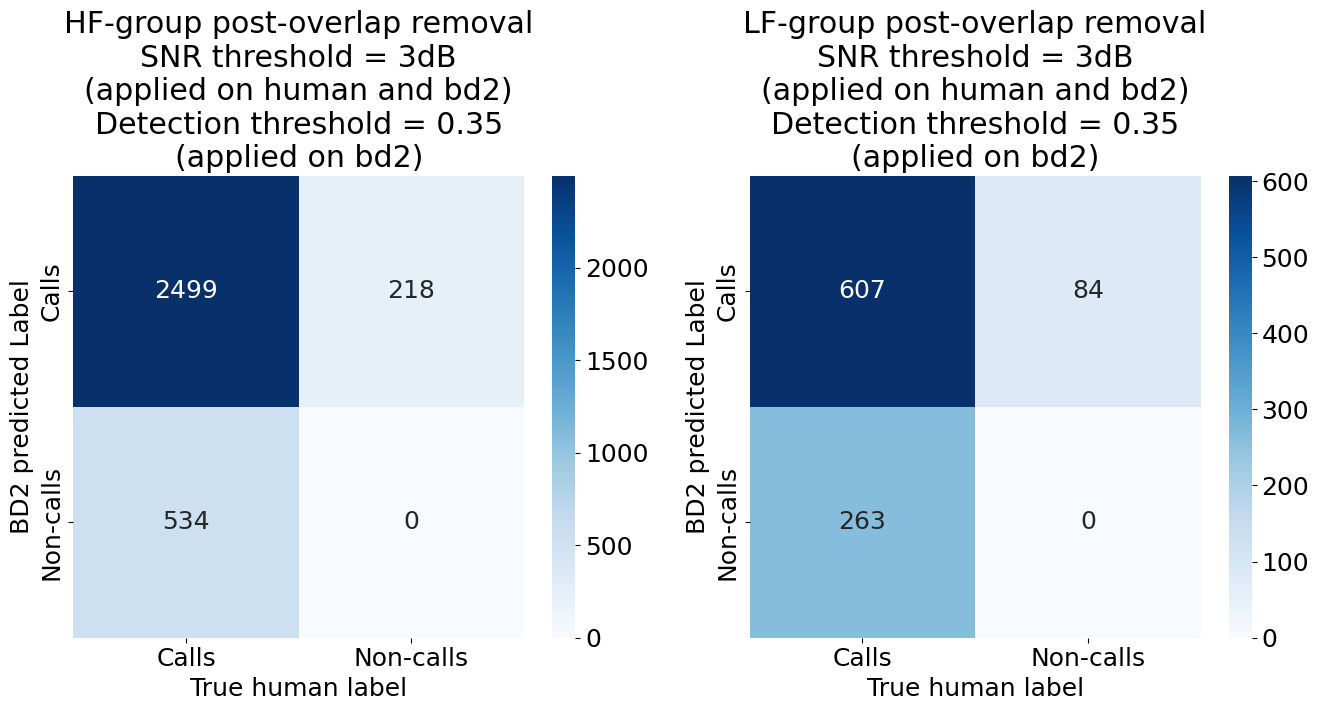

In [74]:
all_files_batdetct2_df = pd.DataFrame()
lf_files_batdetct2_df = pd.DataFrame()
hf_files_batdetct2_df = pd.DataFrame()

lf_files_human_df = pd.DataFrame()
hf_files_human_df = pd.DataFrame()

lf_files_true_positives_batdetct2_df = pd.DataFrame()
hf_files_true_positives_batdetct2_df = pd.DataFrame()
lf_files_true_positives_human_df = pd.DataFrame()
hf_files_true_positives_human_df = pd.DataFrame()

lf_files_false_positives_batdetct2_df = pd.DataFrame()
hf_files_false_positives_batdetct2_df = pd.DataFrame()

lf_files_false_negatives_batdetct2_df = pd.DataFrame()
hf_files_false_negatives_batdetct2_df = pd.DataFrame()

SNR_thresh = 3
detthresh = 0.35
for file_key in file_keys:
    print(f'Computing measures for file {file_key}.WAV')
    wav_filename = file_key
    site = FILE_SITES[file_key]
    plot_file = Path(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=RAVENPRO_TABLE_FORMAT)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)
    bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['adityas_method_snr_dB']>=SNR_thresh].copy()
    lf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].reset_index(drop=True).copy()
    hf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].reset_index(drop=True).copy()
    lf_files_human_df = pd.concat([lf_files_human_df, lf_bd2_human_df_file])
    hf_files_human_df = pd.concat([hf_files_human_df, hf_bd2_human_df_file])

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
    filepath_reduced_overlaps = BD2_DETS_SAVE_DIR / save_loc_reduced_overlaps
    bd2_file_all_dets = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
    bd2_file_all_dets.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
    thresh_applied_bd2_dets = bd2_file_all_dets[bd2_file_all_dets['det_prob']>=detthresh].copy()
    thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['SNR']>=SNR_thresh].copy()

    lf_thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['freq_group']=='LF'].reset_index(drop=True).copy()
    hf_thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['freq_group']=='HF'].reset_index(drop=True).copy()

    all_files_batdetct2_df = pd.concat([all_files_batdetct2_df, thresh_applied_bd2_dets])
    lf_files_batdetct2_df = pd.concat([lf_files_batdetct2_df, lf_thresh_applied_bd2_dets])
    hf_files_batdetct2_df = pd.concat([hf_files_batdetct2_df, hf_thresh_applied_bd2_dets])

    lf_association_matrix, lf_separated_performance_dfs = return_true_positives_using_human_df(lf_bd2_human_df_file, lf_thresh_applied_bd2_dets)
    hf_association_matrix, hf_separated_performance_dfs = return_true_positives_using_human_df(hf_bd2_human_df_file, hf_thresh_applied_bd2_dets)

    lf_human_true_positives = lf_separated_performance_dfs['human_true_positives']
    lf_bd2_false_negatives = lf_separated_performance_dfs['machine_false_negatives']
    lf_bd2_true_positives = lf_separated_performance_dfs['machine_true_positives']
    lf_bd2_false_positives = lf_separated_performance_dfs['machine_false_positives']
    lf_files_true_positives_batdetct2_df = pd.concat([lf_files_true_positives_batdetct2_df, lf_bd2_true_positives])
    lf_files_false_positives_batdetct2_df = pd.concat([lf_files_false_positives_batdetct2_df, lf_bd2_false_positives])
    lf_files_false_negatives_batdetct2_df = pd.concat([lf_files_false_negatives_batdetct2_df, lf_bd2_false_negatives])
    lf_files_true_positives_human_df = pd.concat([lf_files_true_positives_human_df, lf_human_true_positives])

    hf_human_true_positives = hf_separated_performance_dfs['human_true_positives']
    hf_bd2_false_negatives = hf_separated_performance_dfs['machine_false_negatives']
    hf_bd2_true_positives = hf_separated_performance_dfs['machine_true_positives']
    hf_bd2_false_positives = hf_separated_performance_dfs['machine_false_positives']
    hf_files_true_positives_batdetct2_df = pd.concat([hf_files_true_positives_batdetct2_df, hf_bd2_true_positives])
    hf_files_false_positives_batdetct2_df = pd.concat([hf_files_false_positives_batdetct2_df, hf_bd2_false_positives])
    hf_files_false_negatives_batdetct2_df = pd.concat([hf_files_false_negatives_batdetct2_df, hf_bd2_false_negatives])
    hf_files_true_positives_human_df = pd.concat([hf_files_true_positives_human_df, hf_human_true_positives])

lf_confusion_matrix = np.array([[len(lf_files_true_positives_batdetct2_df), len(lf_files_false_positives_batdetct2_df)],
                             [len(lf_files_false_negatives_batdetct2_df), 0]])
hf_confusion_matrix = np.array([[len(hf_files_true_positives_batdetct2_df), len(hf_files_false_positives_batdetct2_df)],
                             [len(hf_files_false_negatives_batdetct2_df), 0]])

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16, 6))
plt.rcParams.update({'font.size':18})

ax1.set_title(f'HF-group post-overlap removal\nSNR threshold = {SNR_thresh}dB\n(applied on human and bd2)\nDetection threshold = {detthresh}\n(applied on bd2)')
sns.heatmap(hf_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Calls', 'Non-calls'], 
                                                    yticklabels=['Calls', 'Non-calls'], ax=ax1)
ax1.set_xlabel('True human label')
ax1.set_ylabel('BD2 predicted Label')

ax2.set_title(f'LF-group post-overlap removal\nSNR threshold = {SNR_thresh}dB\n(applied on human and bd2)\nDetection threshold = {detthresh}\n(applied on bd2)')
sns.heatmap(lf_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Calls', 'Non-calls'], 
                                                    yticklabels=['Calls', 'Non-calls'], ax=ax2)
ax2.set_xlabel('True human label')
ax2.set_ylabel('BD2 predicted Label')

plt.show()

Computing measures for file 20220730_053000.WAV
Computing measures for file 20220826_070000.WAV
Computing measures for file 20220727_083000.WAV
Computing measures for file 20220829_090000.WAV


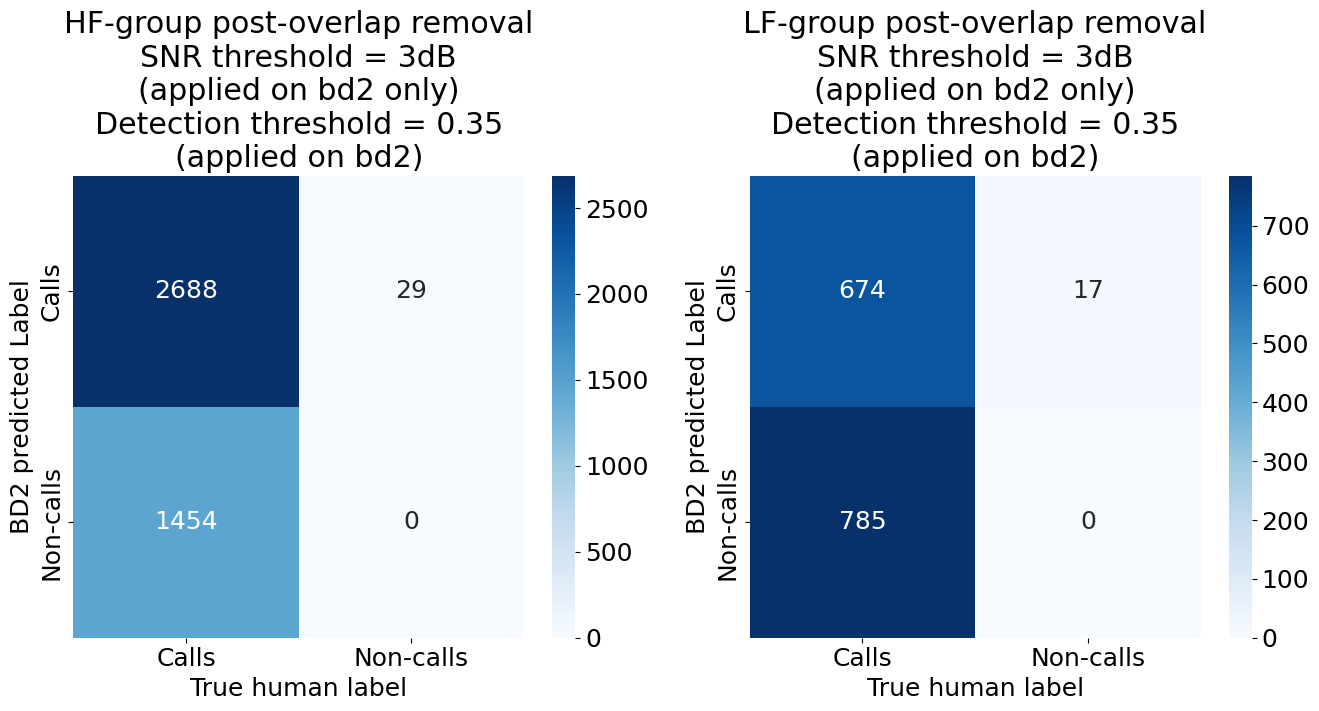

In [76]:
all_files_batdetct2_df = pd.DataFrame()
lf_files_batdetct2_df = pd.DataFrame()
hf_files_batdetct2_df = pd.DataFrame()

lf_files_human_df = pd.DataFrame()
hf_files_human_df = pd.DataFrame()

lf_files_true_positives_batdetct2_df = pd.DataFrame()
hf_files_true_positives_batdetct2_df = pd.DataFrame()
lf_files_true_positives_human_df = pd.DataFrame()
hf_files_true_positives_human_df = pd.DataFrame()

lf_files_false_positives_batdetct2_df = pd.DataFrame()
hf_files_false_positives_batdetct2_df = pd.DataFrame()

lf_files_false_negatives_batdetct2_df = pd.DataFrame()
hf_files_false_negatives_batdetct2_df = pd.DataFrame()

SNR_thresh = 3
detthresh = 0.35
for file_key in file_keys:
    print(f'Computing measures for file {file_key}.WAV')
    wav_filename = file_key
    site = FILE_SITES[file_key]
    plot_file = Path(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=RAVENPRO_TABLE_FORMAT)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)
    # bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['adityas_method_snr_dB']>=SNR_thresh].copy()
    lf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].reset_index(drop=True).copy()
    hf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].reset_index(drop=True).copy()
    lf_files_human_df = pd.concat([lf_files_human_df, lf_bd2_human_df_file])
    hf_files_human_df = pd.concat([hf_files_human_df, hf_bd2_human_df_file])

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
    filepath_reduced_overlaps = BD2_DETS_SAVE_DIR / save_loc_reduced_overlaps
    bd2_file_all_dets = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
    bd2_file_all_dets.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
    thresh_applied_bd2_dets = bd2_file_all_dets[bd2_file_all_dets['det_prob']>=detthresh].copy()
    thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['SNR']>=SNR_thresh].copy()

    lf_thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['freq_group']=='LF'].reset_index(drop=True).copy()
    hf_thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['freq_group']=='HF'].reset_index(drop=True).copy()

    all_files_batdetct2_df = pd.concat([all_files_batdetct2_df, thresh_applied_bd2_dets])
    lf_files_batdetct2_df = pd.concat([lf_files_batdetct2_df, lf_thresh_applied_bd2_dets])
    hf_files_batdetct2_df = pd.concat([hf_files_batdetct2_df, hf_thresh_applied_bd2_dets])

    lf_association_matrix, lf_separated_performance_dfs = return_true_positives_using_human_df(lf_bd2_human_df_file, lf_thresh_applied_bd2_dets)
    hf_association_matrix, hf_separated_performance_dfs = return_true_positives_using_human_df(hf_bd2_human_df_file, hf_thresh_applied_bd2_dets)

    lf_human_true_positives = lf_separated_performance_dfs['human_true_positives']
    lf_bd2_false_negatives = lf_separated_performance_dfs['machine_false_negatives']
    lf_bd2_true_positives = lf_separated_performance_dfs['machine_true_positives']
    lf_bd2_false_positives = lf_separated_performance_dfs['machine_false_positives']
    lf_files_true_positives_batdetct2_df = pd.concat([lf_files_true_positives_batdetct2_df, lf_bd2_true_positives])
    lf_files_false_positives_batdetct2_df = pd.concat([lf_files_false_positives_batdetct2_df, lf_bd2_false_positives])
    lf_files_false_negatives_batdetct2_df = pd.concat([lf_files_false_negatives_batdetct2_df, lf_bd2_false_negatives])
    lf_files_true_positives_human_df = pd.concat([lf_files_true_positives_human_df, lf_human_true_positives])

    hf_human_true_positives = hf_separated_performance_dfs['human_true_positives']
    hf_bd2_false_negatives = hf_separated_performance_dfs['machine_false_negatives']
    hf_bd2_true_positives = hf_separated_performance_dfs['machine_true_positives']
    hf_bd2_false_positives = hf_separated_performance_dfs['machine_false_positives']
    hf_files_true_positives_batdetct2_df = pd.concat([hf_files_true_positives_batdetct2_df, hf_bd2_true_positives])
    hf_files_false_positives_batdetct2_df = pd.concat([hf_files_false_positives_batdetct2_df, hf_bd2_false_positives])
    hf_files_false_negatives_batdetct2_df = pd.concat([hf_files_false_negatives_batdetct2_df, hf_bd2_false_negatives])
    hf_files_true_positives_human_df = pd.concat([hf_files_true_positives_human_df, hf_human_true_positives])

lf_confusion_matrix = np.array([[len(lf_files_true_positives_batdetct2_df), len(lf_files_false_positives_batdetct2_df)],
                             [len(lf_files_false_negatives_batdetct2_df), 0]])
hf_confusion_matrix = np.array([[len(hf_files_true_positives_batdetct2_df), len(hf_files_false_positives_batdetct2_df)],
                             [len(hf_files_false_negatives_batdetct2_df), 0]])

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16, 6))
plt.rcParams.update({'font.size':18})

ax1.set_title(f'HF-group post-overlap removal\nSNR threshold = {SNR_thresh}dB\n(applied on bd2 only)\nDetection threshold = {detthresh}\n(applied on bd2)')
sns.heatmap(hf_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Calls', 'Non-calls'], 
                                                    yticklabels=['Calls', 'Non-calls'], ax=ax1)
ax1.set_xlabel('True human label')
ax1.set_ylabel('BD2 predicted Label')

ax2.set_title(f'LF-group post-overlap removal\nSNR threshold = {SNR_thresh}dB\n(applied on bd2 only)\nDetection threshold = {detthresh}\n(applied on bd2)')
sns.heatmap(lf_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Calls', 'Non-calls'], 
                                                    yticklabels=['Calls', 'Non-calls'], ax=ax2)
ax2.set_xlabel('True human label')
ax2.set_ylabel('BD2 predicted Label')

plt.show()

Computing measures for file 20220730_053000.WAV
Computing measures for file 20220826_070000.WAV
Computing measures for file 20220727_083000.WAV
Computing measures for file 20220829_090000.WAV


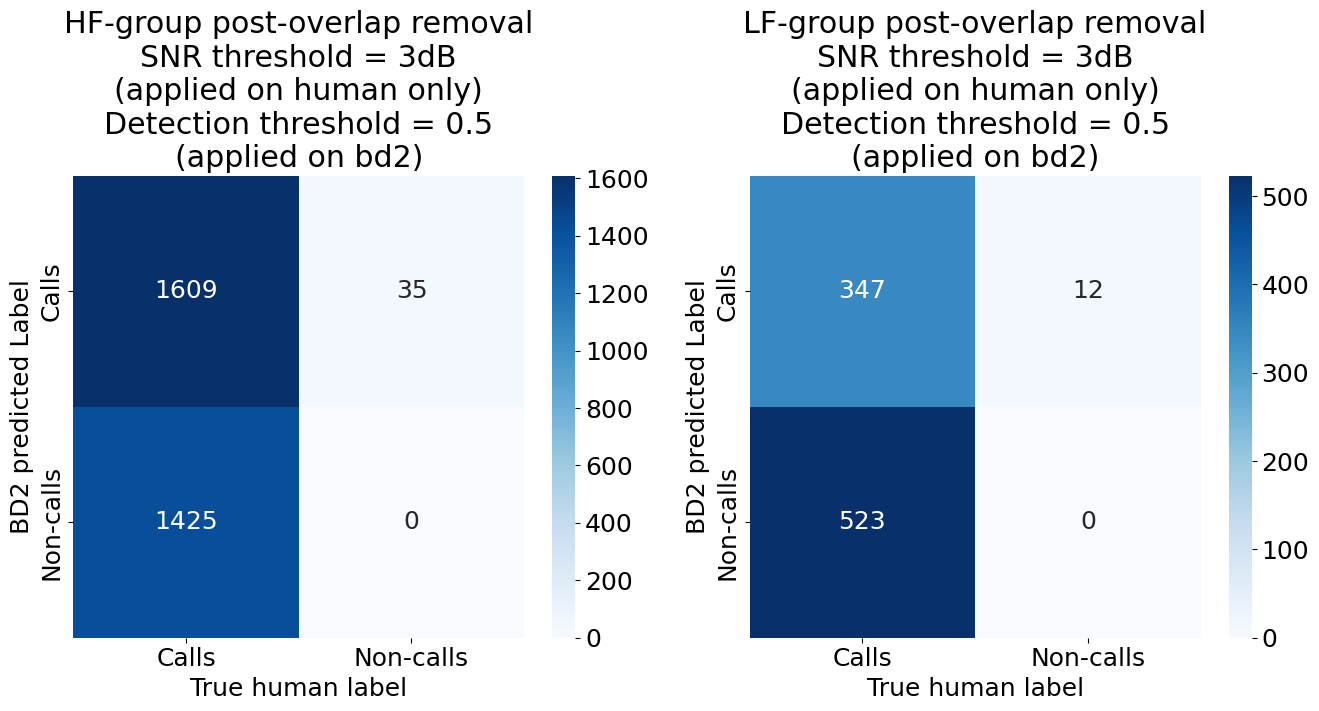

In [78]:
all_files_batdetct2_df = pd.DataFrame()
lf_files_batdetct2_df = pd.DataFrame()
hf_files_batdetct2_df = pd.DataFrame()

lf_files_human_df = pd.DataFrame()
hf_files_human_df = pd.DataFrame()

lf_files_true_positives_batdetct2_df = pd.DataFrame()
hf_files_true_positives_batdetct2_df = pd.DataFrame()
lf_files_true_positives_human_df = pd.DataFrame()
hf_files_true_positives_human_df = pd.DataFrame()

lf_files_false_positives_batdetct2_df = pd.DataFrame()
hf_files_false_positives_batdetct2_df = pd.DataFrame()

lf_files_false_negatives_batdetct2_df = pd.DataFrame()
hf_files_false_negatives_batdetct2_df = pd.DataFrame()

SNR_thresh = 3
detthresh = 0.5
for file_key in file_keys:
    print(f'Computing measures for file {file_key}.WAV')
    wav_filename = file_key
    site = FILE_SITES[file_key]
    plot_file = Path(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=RAVENPRO_TABLE_FORMAT)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)
    bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['adityas_method_snr_dB']>=SNR_thresh].copy()
    lf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].reset_index(drop=True).copy()
    hf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].reset_index(drop=True).copy()
    lf_files_human_df = pd.concat([lf_files_human_df, lf_bd2_human_df_file])
    hf_files_human_df = pd.concat([hf_files_human_df, hf_bd2_human_df_file])

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
    filepath_reduced_overlaps = BD2_DETS_SAVE_DIR / save_loc_reduced_overlaps
    bd2_file_all_dets = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
    bd2_file_all_dets.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
    thresh_applied_bd2_dets = bd2_file_all_dets[bd2_file_all_dets['det_prob']>=detthresh].copy()
    # thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['SNR']>=SNR_thresh].copy()

    lf_thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['freq_group']=='LF'].reset_index(drop=True).copy()
    hf_thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['freq_group']=='HF'].reset_index(drop=True).copy()

    all_files_batdetct2_df = pd.concat([all_files_batdetct2_df, thresh_applied_bd2_dets])
    lf_files_batdetct2_df = pd.concat([lf_files_batdetct2_df, lf_thresh_applied_bd2_dets])
    hf_files_batdetct2_df = pd.concat([hf_files_batdetct2_df, hf_thresh_applied_bd2_dets])

    lf_association_matrix, lf_separated_performance_dfs = return_true_positives_using_human_df(lf_bd2_human_df_file, lf_thresh_applied_bd2_dets)
    hf_association_matrix, hf_separated_performance_dfs = return_true_positives_using_human_df(hf_bd2_human_df_file, hf_thresh_applied_bd2_dets)

    lf_human_true_positives = lf_separated_performance_dfs['human_true_positives']
    lf_bd2_false_negatives = lf_separated_performance_dfs['machine_false_negatives']
    lf_bd2_true_positives = lf_separated_performance_dfs['machine_true_positives']
    lf_bd2_false_positives = lf_separated_performance_dfs['machine_false_positives']
    lf_files_true_positives_batdetct2_df = pd.concat([lf_files_true_positives_batdetct2_df, lf_bd2_true_positives])
    lf_files_false_positives_batdetct2_df = pd.concat([lf_files_false_positives_batdetct2_df, lf_bd2_false_positives])
    lf_files_false_negatives_batdetct2_df = pd.concat([lf_files_false_negatives_batdetct2_df, lf_bd2_false_negatives])
    lf_files_true_positives_human_df = pd.concat([lf_files_true_positives_human_df, lf_human_true_positives])

    hf_human_true_positives = hf_separated_performance_dfs['human_true_positives']
    hf_bd2_false_negatives = hf_separated_performance_dfs['machine_false_negatives']
    hf_bd2_true_positives = hf_separated_performance_dfs['machine_true_positives']
    hf_bd2_false_positives = hf_separated_performance_dfs['machine_false_positives']
    hf_files_true_positives_batdetct2_df = pd.concat([hf_files_true_positives_batdetct2_df, hf_bd2_true_positives])
    hf_files_false_positives_batdetct2_df = pd.concat([hf_files_false_positives_batdetct2_df, hf_bd2_false_positives])
    hf_files_false_negatives_batdetct2_df = pd.concat([hf_files_false_negatives_batdetct2_df, hf_bd2_false_negatives])
    hf_files_true_positives_human_df = pd.concat([hf_files_true_positives_human_df, hf_human_true_positives])

lf_confusion_matrix = np.array([[len(lf_files_true_positives_batdetct2_df), len(lf_files_false_positives_batdetct2_df)],
                             [len(lf_files_false_negatives_batdetct2_df), 0]])
hf_confusion_matrix = np.array([[len(hf_files_true_positives_batdetct2_df), len(hf_files_false_positives_batdetct2_df)],
                             [len(hf_files_false_negatives_batdetct2_df), 0]])

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16, 6))
plt.rcParams.update({'font.size':18})

ax1.set_title(f'HF-group post-overlap removal\nSNR threshold = {SNR_thresh}dB\n(applied on human only)\nDetection threshold = {detthresh}\n(applied on bd2)')
sns.heatmap(hf_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Calls', 'Non-calls'], 
                                                    yticklabels=['Calls', 'Non-calls'], ax=ax1)
ax1.set_xlabel('True human label')
ax1.set_ylabel('BD2 predicted Label')

ax2.set_title(f'LF-group post-overlap removal\nSNR threshold = {SNR_thresh}dB\n(applied on human only)\nDetection threshold = {detthresh}\n(applied on bd2)')
sns.heatmap(lf_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Calls', 'Non-calls'], 
                                                    yticklabels=['Calls', 'Non-calls'], ax=ax2)
ax2.set_xlabel('True human label')
ax2.set_ylabel('BD2 predicted Label')

plt.show()